# 04 — Configuration 4 — Horizon de prédiction H = 1, 6, 12, 24, 168 h

**Question.** Comment la qualité et la stabilité évoluent-elles avec l'horizon ?

**Hypothèses.** L'erreur croît avec l'horizon jusqu'au cycle journalier ; au-delà (168 h), l'information nuageuse récente est perdue et la prévision tend vers une climatologie conditionnelle. La comparaison à la persistance est faite au même horizon.

**Paramètres fixés.** P, L et traitement des canaux retenus aux configurations 1 à 3.

**Protocole** (identique pour toutes les configurations — module `patchtst_pv`, section 8) :
1. entraînement sur Train (2019–2021), arrêt précoce sur Val (01–09/2022), **5 graines** ;
2. précision sur **toutes les origines horaires du Test** (10/2022–05/2023) : RMSE, MAE, nRMSE = RMSE / moyenne, R², MBE ;
3. **robustesse** : écart-type sur les graines et bruit gaussien 5 % sur les exogènes (rejet si ΔRMSE > 15 %) ;
4. **stabilité** : rolling forecast de 30 jours sans ré-entraînement, dérive = RMSE(J24–30) / RMSE(J1–7) (objectif < 1,2) ;
5. **efficience** : temps d'inférence d'un échantillon (< 100 ms) et taille des poids (< 50 Mo) ;
6. **score de décision** de `projet.md` (brut et normalisé) et tests de Diebold-Mariano contre la persistance et la moyenne.

> Les entraînements sont mis en cache (`cache/<configuration>/`) : supprimer le dossier correspondant relance
> l'entraînement complet depuis ce notebook.

In [1]:
# --- Environnement commun à tous les notebooks -------------------------------
import sys, warnings
from pathlib import Path
RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m          # module commun de l'étude (entièrement commenté)
import figures_style as fs       # charte graphique des figures de l'article
fs.appliquer()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analyse as an, organigramme as org, json, dataclasses
from nb_config import configs_de

## 1. Organigramme de la configuration

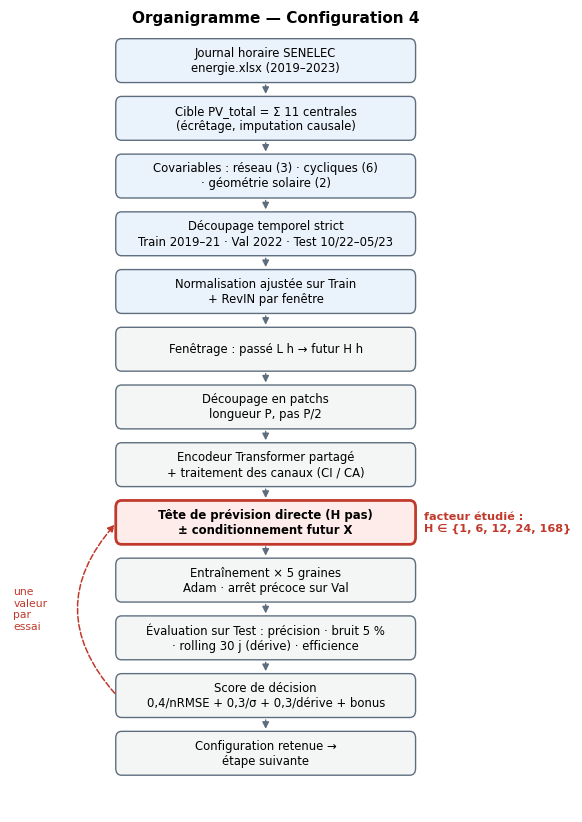

In [2]:
org.tracer(4, "Organigramme — Configuration 4", "org_config4")

## 2. Configurations évaluées

In [3]:
jeu = m.construire_jeu()
configs = configs_de(4)
pd.DataFrame([dict(nom=c.nom(), P=c.P, L=c.L, H=c.H, canaux=c.mode_canaux, futur_connu=c.futur_connu,
                   porte_physique=c.porte_physique, n_patchs=c.n_patchs) for c in configs])

,nom,P,L,H,canaux,futur_connu,porte_physique,n_patchs
0,PatchTST-CAX_P12_L168_H1,12,168,1,CA,True,False,27
1,PatchTST-CAX_P12_L168_H6,12,168,6,CA,True,False,27
2,PatchTST-CAX_P12_L168_H12,12,168,12,CA,True,False,27
3,PatchTST-CAX_P12_L168_H24,12,168,24,CA,True,False,27
4,PatchTST-CAX_P12_L168_H168,12,168,168,CA,True,False,27


## 3. Entraînement et évaluation (5 graines chacune)

In [4]:
resultats = [m.evaluer_configuration(c, jeu) for c in configs]   # relit le cache s'il existe
detail = pd.DataFrame([dict(configuration=r["nom"], **{k: g[k] for k in
         ["graine", "epoques", "duree_s", "RMSE", "MAE", "nRMSE", "R2", "degradation_bruit", "drift_7j", "drift_J30_J1"]})
         for r in resultats for g in r["par_graine"]])
detail

,configuration,graine,epoques,duree_s,RMSE,MAE,nRMSE,R2,degradation_bruit,drift_7j,drift_J30_J1
0,PatchTST-CAX_P12_L168_H1,0,19,3902.7933,4.3481,2.9006,0.0982,0.9939,0.0019,0.5414,0.6541
1,PatchTST-CAX_P12_L168_H1,1,20,668.6840,4.4972,2.9607,0.1016,0.9935,0.0055,0.5414,0.7146
2,PatchTST-CAX_P12_L168_H1,2,15,499.8124,5.1848,3.5265,0.1171,0.9914,0.0010,0.6403,0.7653
3,PatchTST-CAX_P12_L168_H1,3,11,371.3378,6.1248,4.2937,0.1383,0.9880,0.0022,0.5894,0.8838
4,PatchTST-CAX_P12_L168_H1,4,23,774.1646,4.4976,3.2685,0.1016,0.9935,0.0044,0.5915,0.7483
5,PatchTST-CAX_P12_L168_H6,0,22,752.5926,7.5286,4.4202,0.1699,0.9818,0.0049,0.5142,0.9863
6,PatchTST-CAX_P12_L168_H6,1,21,729.4079,7.6890,4.4591,0.1735,0.9810,0.0039,0.5347,1.1254
7,PatchTST-CAX_P12_L168_H6,2,16,554.5746,7.6661,4.4654,0.1730,0.9811,0.0043,0.5462,0.9723
8,PatchTST-CAX_P12_L168_H6,3,13,433.7638,8.0239,4.8692,0.1811,0.9793,0.0048,0.5840,1.0248
9,PatchTST-CAX_P12_L168_H6,4,16,538.6127,7.7957,4.6027,0.1759,0.9805,0.0041,0.5649,0.9019


## 4. Tableau comparatif des métriques (moyenne sur 5 graines) et références naïves

In [5]:
tableau = m.tableau_comparatif(resultats)
_, vrai0, orig0 = an.charger_predictions(resultats[0]["nom"])
refs = an.lignes_references(jeu, orig0, vrai0, configs[0].H) if len({c.H for c in configs}) == 1 else None
colonnes = ["configuration", "RMSE", "RMSE_std", "MAE", "nRMSE", "nRMSE_jour", "R2", "MBE", "degradation_bruit",
            "drift_J30_J1", "drift_7j", "inference_ms", "taille_Mo", "n_parametres", "score", "score_normalise", "rejete_bruit"]
affiche = pd.concat([tableau[colonnes], refs], ignore_index=True) if refs is not None else tableau[colonnes]
affiche.to_csv(m.DOSSIER_TABLEAUX / "tableau_config4.csv", index=False)
affiche.round(4)

,configuration,RMSE,RMSE_std,MAE,nRMSE,nRMSE_jour,R2,MBE,degradation_bruit,drift_J30_J1,drift_7j,inference_ms,taille_Mo,n_parametres,score,score_normalise,rejete_bruit
0,PatchTST-CAX_P12_L168_H1,4.9305,0.7425,3.3900,0.1114,0.1128,0.9921,1.2265,0.0030,0.7532,0.5808,2.8717,0.5748,146858,4.7125,0.5000,False
1,PatchTST-CAX_P12_L168_H6,7.7406,0.1847,4.5633,0.1747,0.1830,0.9808,0.2435,0.0044,1.0021,0.5488,2.6767,0.6078,155503,4.6610,0.5688,False
2,PatchTST-CAX_P12_L168_H12,8.6091,0.0554,5.0398,0.1942,0.2031,0.9762,0.0719,0.0052,0.9113,0.5761,2.6194,0.6473,165877,8.1922,0.5713,False
3,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,5.2086,0.2037,0.2146,0.9739,-0.0050,0.0044,0.5752,0.5839,2.9255,0.7265,186625,5.7561,0.5267,False
4,PatchTST-CAX_P12_L168_H168,11.3349,0.0957,6.7918,0.2562,0.2713,0.9587,-0.4605,0.0040,0.5823,0.5985,2.9782,1.6762,435601,5.3970,0.3824,False


*Lecture des colonnes.* `RMSE_std` : écart-type sur les 5 graines (robustesse). `nRMSE_jour` : nRMSE restreint aux heures
diurnes. `degradation_bruit` : hausse relative du RMSE sous bruit de 5 % sur les exogènes. `drift_J30_J1` : ratio brut de
`projet.md` (sensible à la nébulosité de deux journées isolées), `drift_7j` : ratio lissé retenu pour le score.
`score` : formule brute de `projet.md` ; `score_normalise` : chaque critère ramené à [0, 1] entre les variantes comparées.

In [6]:
dm = an.tests_dm(jeu, resultats)
dm.round(4)

,configuration,reference,skill_score,DM,p_valeur
0,PatchTST-CAX_P12_L168_H1,persistance,0.5664,-15.3109,0.0000
1,PatchTST-CAX_P12_L168_H1,moyenne 7 j,0.5836,-17.1403,0.0000
2,PatchTST-CAX_P12_L168_H6,persistance,0.2591,-4.8205,0.0000
3,PatchTST-CAX_P12_L168_H6,moyenne 7 j,0.2885,-5.2440,0.0000
4,PatchTST-CAX_P12_L168_H12,persistance,0.1726,-3.6661,0.0002
5,PatchTST-CAX_P12_L168_H12,moyenne 7 j,0.2054,-4.4607,0.0000
6,PatchTST-CAX_P12_L168_H24,persistance,0.1314,-2.9661,0.0030
7,PatchTST-CAX_P12_L168_H24,moyenne 7 j,0.1659,-3.0762,0.0021
8,PatchTST-CAX_P12_L168_H168,persistance,0.1762,-2.5188,0.0118
9,PatchTST-CAX_P12_L168_H168,moyenne 7 j,0.0499,-0.6551,0.5125


## 5. Chapelet des graines et stabilité sur 30 jours

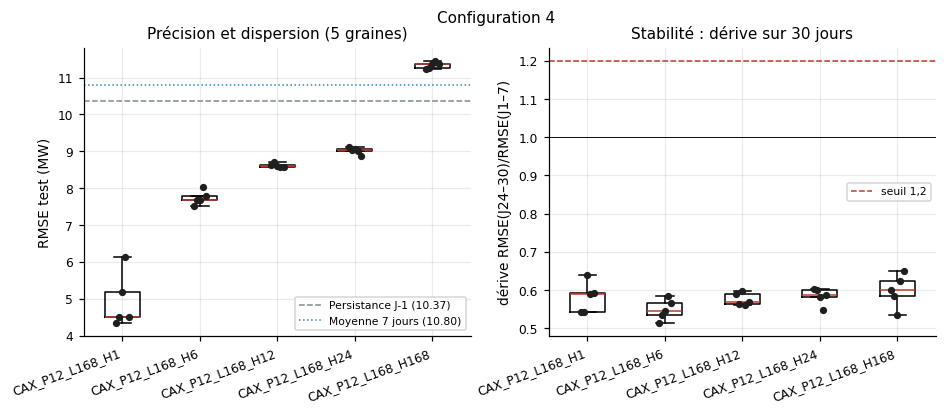

In [7]:
an.fig_chapelet(resultats, jeu, "fig_config4_chapelet", "Configuration 4")

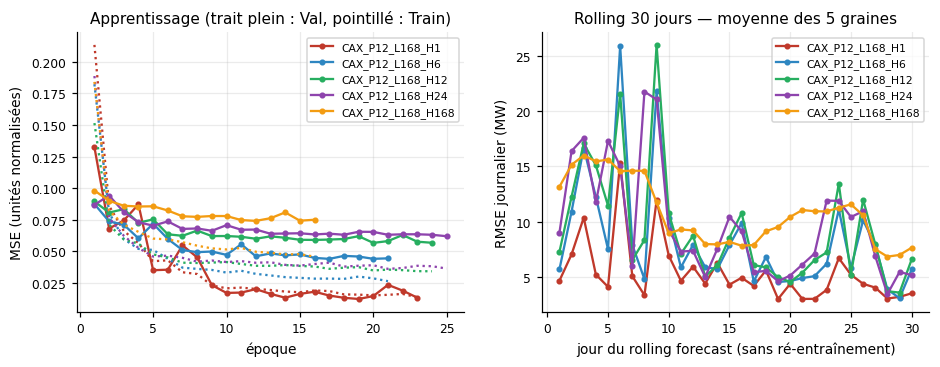

In [8]:
an.fig_apprentissage_et_derive(resultats, "fig_config4_apprentissage_derive")

## 6. Série observée vs prédite — meilleur modèle de la configuration

Configuration retenue : PatchTST-CAX_P12_L168_H12


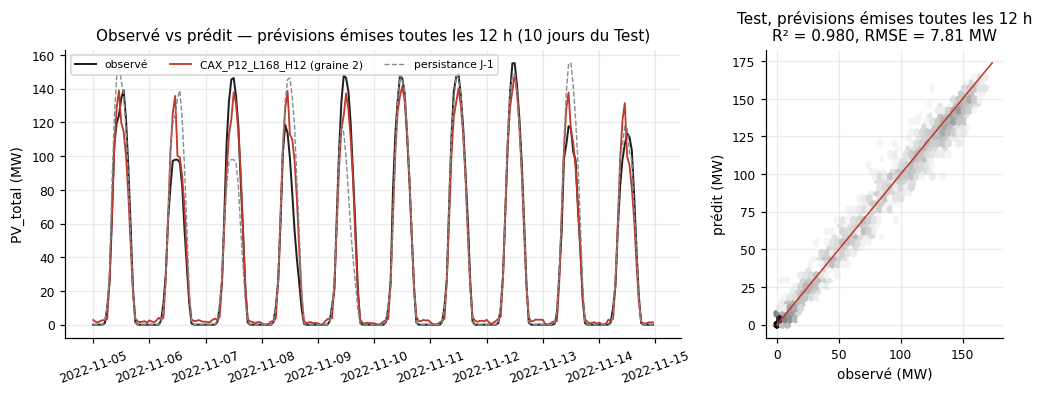

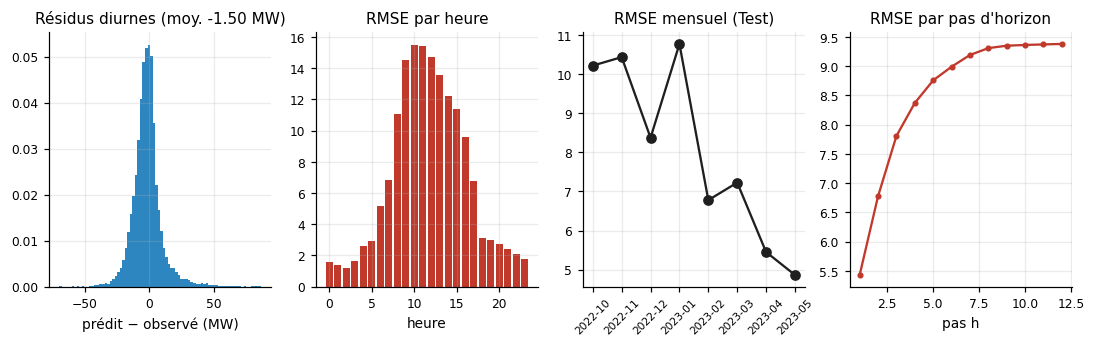

In [9]:
retenu = an.selection_precedente("config4_horizon")
print("Configuration retenue :", retenu)
res_retenu = [r for r in resultats if r["nom"] == retenu][0]
an.fig_observe_predit(res_retenu, jeu, "fig_config4_observe_predit")
an.fig_residus(res_retenu, jeu, "fig_config4_residus")

### Conclusion de la configuration 4

**Meilleur score : `PatchTST-CAX_P12_L168_H12`.** Le score compare ici des *tâches* différentes : l'erreur à 1 h est mécaniquement plus faible qu'à 24 h. L'horizon n'est donc pas choisi par le score. Le modèle final (notebook 05) est évalué à l'horizon opérationnel J+1 (24 h), et cette configuration décrit comment la performance et la stabilité évoluent avec l'horizon ; la comparaison pertinente est le gain par rapport à la persistance **au même horizon**.

- `PatchTST-CAX_P12_L168_H1` : RMSE = 4,93 ± 0,74 MW, nRMSE = 0,111, gain vs persistance = +52,5 %, dégradation sous bruit = +0,3 %, dérive 7 j = 0,58, inférence = 2,9 ms, 146 858 paramètres.
- `PatchTST-CAX_P12_L168_H6` : RMSE = 7,74 ± 0,18 MW, nRMSE = 0,175, gain vs persistance = +25,4 %, dégradation sous bruit = +0,4 %, dérive 7 j = 0,55, inférence = 2,7 ms, 155 503 paramètres.
- `PatchTST-CAX_P12_L168_H12` : RMSE = 8,61 ± 0,06 MW, nRMSE = 0,194, gain vs persistance = +17,1 %, dégradation sous bruit = +0,5 %, dérive 7 j = 0,58, inférence = 2,6 ms, 165 877 paramètres.
- `PatchTST-CAX_P12_L168_H24` : RMSE = 9,02 ± 0,10 MW, nRMSE = 0,204, gain vs persistance = +13,2 %, dégradation sous bruit = +0,4 %, dérive 7 j = 0,58, inférence = 2,9 ms, 186 625 paramètres.
- `PatchTST-CAX_P12_L168_H168` : RMSE = 11,33 ± 0,10 MW, nRMSE = 0,256, gain vs persistance = +17,9 %, dégradation sous bruit = +0,4 %, dérive 7 j = 0,60, inférence = 3,0 ms, 435 601 paramètres.

- Écart de RMSE entre la meilleure et la moins bonne variante : 6,40 MW (129,9 %).
- Toutes les variantes respectent le critère de robustesse (dégradation < 15 %) : oui ; toutes respectent l'objectif de dérive < 1,2 : oui ; toutes respectent l'efficience (< 100 ms, < 50 Mo) : oui.